<a href="https://colab.research.google.com/github/patelmrunal/machine-learning-pytorch/blob/main/02_pytorch_neural_network_classification_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 Make classification data and get it ready

In [132]:
# Neural Network Classification with PyTorch

import sklearn

In [133]:
from sklearn.datasets import make_circles

# Make sample
n_samples = 1000

# Create circle
x, y = make_circles(n_samples,
                    noise=0.04,
                    random_state=42)

In [134]:
len(x),  len(y)

(1000, 1000)

In [135]:
print(f"first 10 of x: {x[:10]}")
print(f"first 10 of y: {y[:10]}")

first 10 of x: [[ 0.74822656  0.23908325]
 [-0.74509559  0.16097526]
 [-0.82262532  0.19762051]
 [-0.41143316  0.68255648]
 [ 0.44390494 -0.89582949]
 [-0.47476593  0.69223611]
 [-0.01484687  0.80448601]
 [ 0.76556811  0.15364287]
 [-0.17250712 -0.79664632]
 [-0.11605096  1.03185826]]
first 10 of y: [1 1 1 1 0 1 1 1 1 0]


In [136]:
import pandas as pd

# Correctly create the DataFrame by passing a single dictionary
circles = pd.DataFrame({
    "X1": x[:, 0],
    "X2": x[:, 1],
    "label": y
})

circles.head(10)

,X1,X2,label
0,0.748227,0.239083,1
1,-0.745096,0.160975,1
2,-0.822625,0.197621,1
3,-0.411433,0.682556,1
4,0.443905,-0.895829,0
5,-0.474766,0.692236,1
6,-0.014847,0.804486,1
7,0.765568,0.153643,1
8,-0.172507,-0.796646,1
9,-0.116051,1.031858,0


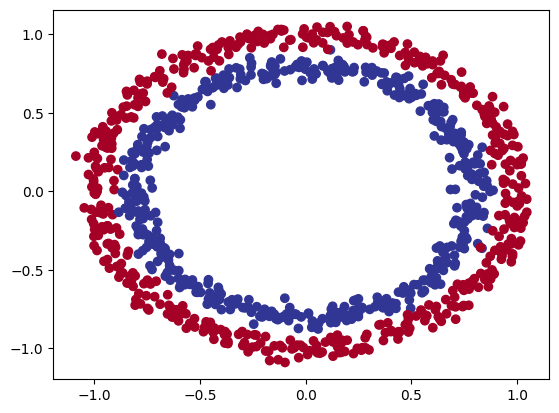

In [137]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x = x[:,0],
            y = x[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

### 1.1 Check input and output shape

In [138]:
x.shape, y.shape

((1000, 2), (1000,))

In [139]:
x

array([[ 0.74822656,  0.23908325],
       [-0.74509559,  0.16097526],
       [-0.82262532,  0.19762051],
       ...,
       [-0.13256546, -0.8180725 ],
       [ 0.66563305, -0.78034584],
       [ 0.27973578,  0.96559198]])

In [140]:
# View the first example of feature and index

x_sample = x[0]
y_sample = y[0]

print(f"print value of sample sample X: {x_sample}, sample Y: {y_sample}")

print value of sample sample X: [0.74822656 0.23908325], sample Y: 1


### 1.2 Turn data into tensor and create train and test splits data

In [141]:
import torch
torch.__version__

'2.10.0+cu128'

In [142]:
type(x), type(y), x.dtype, y.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'), dtype('int64'))

In [143]:
import numpy as np

# Turn data into tensor only if they are numpy arrays
if isinstance(x, np.ndarray):
    x = torch.from_numpy(x).type(torch.float)
if isinstance(y, np.ndarray):
    y = torch.from_numpy(y).type(torch.float)

# View first 5 elements (slicing rows, not columns)
print(f"X: {x[:5]}")
print(f"y: {y[:5]}")

X: tensor([[ 0.7482,  0.2391],
        [-0.7451,  0.1610],
        [-0.8226,  0.1976],
        [-0.4114,  0.6826],
        [ 0.4439, -0.8958]])
y: tensor([1., 1., 1., 1., 0.])


In [144]:
type(x), type(y), x.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [145]:
# splits data into training and datasets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.20, #20% data test and 85% data will be train
                                                    random_state=42)

len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

##  2 Buliding a Model

In [146]:
import torch
from torch import  nn

In [147]:
# set up device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [148]:
x_train.shape

torch.Size([800, 2])

In [149]:
# Make a model that subclass is nn.module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Create a nn.Linear layers
        self.layer_1 = nn.Linear(in_features= 2, out_features= 8)
        self.layer_2 = nn.Linear(in_features=8, out_features=1)

    # Defibe a forward method
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2

# Instantiate an instance of our model class
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [150]:
device

'cuda'

In [151]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [152]:
# Replicate model using nn.sequential

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=128),
    nn.Linear(in_features=128, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Linear(in_features=128, out_features=1, bias=True)
)

In [153]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 5.0776e-01, -1.9869e-01],
                      [-6.0144e-02, -3.3672e-02],
                      [-6.5664e-01,  2.2241e-01],
                      [-2.5298e-01, -3.5790e-02],
                      [-1.3884e-01,  6.2283e-01],
                      [ 3.0876e-01, -3.0935e-01],
                      [-7.7582e-02, -5.2691e-01],
                      [-1.7217e-01, -8.5580e-02],
                      [ 1.9641e-01, -6.0981e-01],
                      [ 6.5555e-01,  4.5337e-01],
                      [ 5.1812e-01, -4.5146e-01],
                      [ 3.2613e-01,  7.0279e-01],
                      [ 2.1954e-01,  3.0726e-01],
                      [ 2.4657e-01,  5.5211e-01],
                      [-5.7855e-01,  3.0251e-01],
                      [ 5.4705e-01, -5.5683e-01],
                      [-3.9937e-01,  1.1430e-01],
                      [ 3.3624e-01,  2.5562e-02],
                      [ 6.9884e-01,  2.1930e-02],
                      [-

In [154]:
# Make Predctions
with torch.inference_mode():
    untrained_preds = model_0(x_test.to(device))
print(f"untrained preds: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"lenght of test sample {len(x_test)}, shape: {x_test.shape}")
print(f"First 20 preds: \n{torch.round(untrained_preds[:10])}")
print(f"First 20 labels: \n {y_test[:10]}")

untrained preds: 200, shape: torch.Size([200, 1])
lenght of test sample 200, shape: torch.Size([200, 2])
First 20 preds: 
tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-1.],
        [-1.],
        [-1.],
        [-0.],
        [-0.]], device='cuda:0')
First 20 labels: 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Set up loss function and optimizer

In [155]:
# Setup the loss function

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [156]:
# Calculate the accuracy

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 3 Train model

In [157]:
## View the first 5 output of the forward pass on test data

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.1577],
        [-0.3153],
        [-0.0462],
        [-0.1918],
        [-0.4912]], device='cuda:0')

In [158]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [159]:
# Use the sigmoid activation function on our model logits

y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.4607],
        [0.4218],
        [0.4885],
        [0.4522],
        [0.3796]], device='cuda:0')

In [160]:
# Find the predicted labels
y_preds = torch.round(y_preds_probs)

# In full
y_preds_label = torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

# Check for quality
print(torch.eq(y_preds.squeeze(), y_preds_label.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

### 3.1 Buliding Testing and Training loop

In [161]:
torch.cuda.manual_seed(42)

epochs = 100

# Put data to the target device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# Buliding training and evaluation loop
for epoch in range(epochs):
    # Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #2. Calculate the loss
    ###loss = loss_fn(torch.sigmoid(y_logits), y_train)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    #3. Optimizer zero
    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    #5. optimizer step
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        # Forward pass
        test_logits = model_0(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        # Calculate the loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    # Print out what happen
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71459 | Acc: 41.75% | Test Loss: 0.69774 | Test Acc: 47.50%
Epoch: 10 | Loss: 0.69302 | Acc: 51.00% | Test Loss: 0.69460 | Test Acc: 46.50%
Epoch: 20 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69468 | Test Acc: 46.00%
Epoch: 30 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 40 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 50 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 60 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 70 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 80 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 90 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%


##  4 Make predictions and evaluate the model



In [162]:
import requests
from pathlib import Path

# Download helper function from PyTorch repo

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


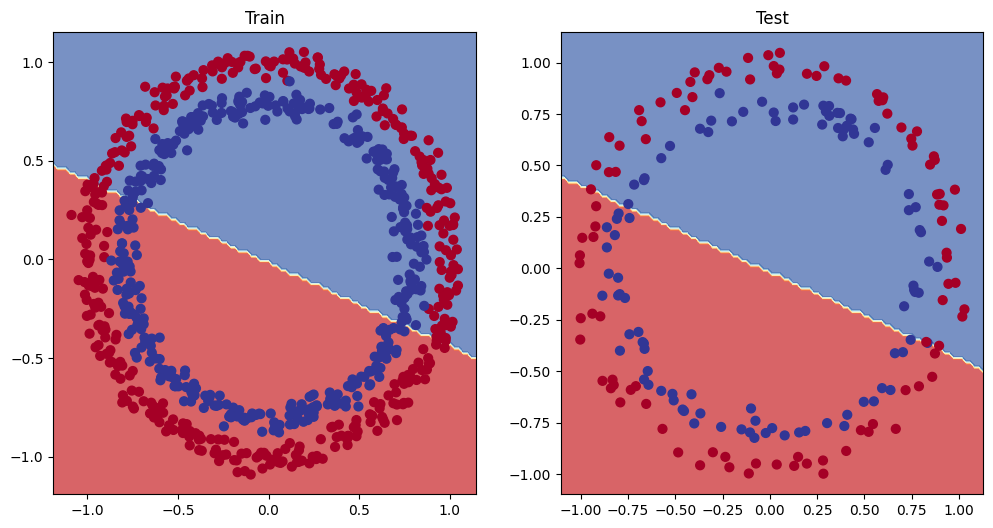

In [164]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)